# Vehicle Price Adequacy Classification Model Analysis

This notebook builds a model that classifies vehicle price adequacy into 3 classes based on residuals from a regression model (Enhanced Linear Regression).

## Analysis Goals

- Generate price adequacy labels for each vehicle based on regression model residuals
- Compare multiple classification algorithms using K-Fold Cross Validation to select the optimal model
- Apply the selected model to a large dataset of approximately 54,805 vehicles to classify price adequacy
- Derive the overall pricing tendency of the dataset from the classification results

## Classification Criteria

| Class | Label | Description |
|--------|------|------|
| 0 | Underpriced | Actual price < Predicted price (selling below market value) |
| 1 | Fairly Priced | Actual price ≈ Predicted price (appropriately priced) |
| 2 | Overpriced | Actual price > Predicted price (selling above market value) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
N_FOLDS     = 5
print('Libraries loaded successfully')

라이브러리 로드 완료


## Step 1. Load Data

Load the two datasets used in this analysis.

| File | Description | Role |
|------|------|------|
| `preprocessed_vehicles.csv` | 7,192 rows × 52 columns (preprocessed original data) | Regression residual calculation + classification model training |
| `preprocessed_vehicle_classification_scaled.csv` | 54,805 rows × 52 columns (scaled) | Target dataset for classification model application |

In [2]:
df_train = pd.read_csv('preprocessed_vehicles.csv')
print('Training data shape:', df_train.shape)

df_test = pd.read_csv('preprocessed_vehicle_classification_scaled.csv')
print('Test data shape:', df_test.shape)

학습 데이터 크기: (7192, 52)
테스트 데이터 크기: (54805, 52)


## Step 2. Residual Calculation and Label Generation via Enhanced Regression Model

Using the **Enhanced Linear Regression model** (including estimate_msrp) built in the regression analysis step,
calculate predicted prices for 7,192 vehicles and generate price adequacy labels based on residuals.

> **Why use the Enhanced model?**
> - The 7,192 training samples have `estimate_msrp`, so the Enhanced model can be used
> - The Enhanced model outperforms Baseline in all metrics: R², Adjusted R², and RMSE
> - More accurate predictions → more meaningful residuals → more reliable labels
> - By excluding `estimate_msrp` from classification features, the model can also be applied to the 54,805-row test data

### Residual Calculation

$$\text{residual} = \text{actual price} - \text{predicted price}$$

- residual < 0 → Actual price is lower than predicted → **Underpriced (0)**
- residual ≈ 0 → Actual price is similar to predicted → **Fairly Priced (1)**
- residual > 0 → Actual price is higher than predicted → **Overpriced (2)**

### Label Boundary Setting: Percentile Method

The **33rd / 67th percentiles** of residuals are used as boundary values.

Reasons for choosing this approach:

- **No absolute standard**: Since there is no absolute standard for defining the "true fair price" of a vehicle, judging by **relative position** within the entire data is reasonable.
- **Guaranteed equal class distribution**: The percentile method always maintains approximately 33% per class, preventing class imbalance. A fixed threshold approach can cause imbalance where a specific class exceeds 90%.
- **Training stability**: An equal class distribution allows the model to learn stably without biasing toward a specific class.

In [3]:
target_col  = 'price'
exclude_reg = ['price', 'model']
reg_feature_cols = [c for c in df_train.columns if c not in exclude_reg]

X_reg = df_train[reg_feature_cols].copy()
y_reg = df_train[target_col].copy()

numeric_cols = ['condition', 'odometer', 'vehicle_age', 'estimate_msrp']
scaler_reg   = StandardScaler()
X_reg[numeric_cols] = scaler_reg.fit_transform(X_reg[numeric_cols])

lr_model = LinearRegression()
lr_model.fit(X_reg, y_reg)
y_pred_reg = lr_model.predict(X_reg)

residuals = y_reg - y_pred_reg

# Print residual std and R² (mean always converges to 0 due to regression model properties)
print(f'Residual Std Dev = {residuals.std():,.0f}')
print(f'R² = {lr_model.score(X_reg, y_reg):.4f}')

p33 = np.percentile(residuals, 33)
p67 = np.percentile(residuals, 67)
print(f'\nBoundaries:  33rd percentile = ${p33:,.0f}  |  67th percentile = ${p67:,.0f}')

price_class = pd.Series(1, index=df_train.index, name='price_class')
price_class[residuals < p33] = 0
price_class[residuals > p67] = 2

df_train['residual']    = residuals.values
df_train['price_class'] = price_class.values

print('\nLabel distribution:')
counts = df_train['price_class'].value_counts().sort_index()
label_names = {0: 'Underpriced', 1: 'Fairly Priced', 2: 'Overpriced'}
for cls, cnt in counts.items():
    print(f'  {cls} ({label_names[cls]}): {cnt} samples  ({cnt/len(df_train)*100:.1f}%)')

잔차 표준편차 = 4,972
R² = 0.8471

경계값:  33번째 백분위수 = $-1,920  |  67번째 백분위수 = $1,447

라벨 분포:
  0 (Underpriced): 2374건  (33.0%)
  1 (Fairly Priced): 2444건  (34.0%)
  2 (Overpriced): 2374건  (33.0%)


## Step 3. Check Class Distribution

Before training the classification model, visually confirm the number of data points in each class.

If class imbalance is severe, the model may be biased toward predicting only the majority class,
so it must be checked in advance.

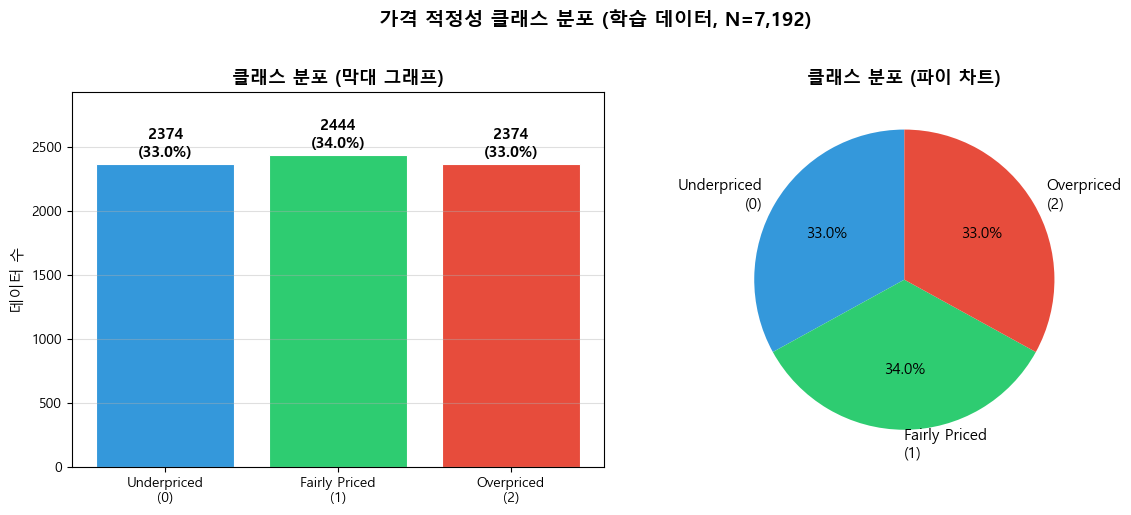


클래스 분포가 균등하여 클래스 불균형 문제 없음 → 별도의 SMOTE 처리 불필요


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_train['price_class'].value_counts().sort_index()
colors = ['#3498DB', '#2ECC71', '#E74C3C']
class_labels = ['Underpriced\n(0)', 'Fairly Priced\n(1)', 'Overpriced\n(2)']

bars = axes[0].bar(class_labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{cnt}\n({cnt/len(df_train)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.4)

axes[1].pie(
    counts.values, labels=class_labels, colors=colors,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('Price Adequacy Class Distribution (Training Data, N=7,192)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\nClass distribution is balanced — no class imbalance → no SMOTE needed')

Label generation based on percentiles resulted in an equal distribution of approximately **33% / 34% / 33%** across the three classes.
Since there is no class imbalance, proceed with classification model training without additional processing such as SMOTE.

## Step 4. Feature Alignment and Preprocessing

Align features of the training data (7,192 rows) and test data (54,805 rows) identically.

- **Residual calculation (Step 2)**: Uses Enhanced model → includes `estimate_msrp`
- **Classification model features**: Excludes `estimate_msrp` → applicable to 54,805-row test data

| Category | Features | Handling |
|------|-----------|----------|
| Training data only | `manufacturer_chrysler` | Excluded from classification features |
| Test data only | `manufacturer_mercedes-benz`, `title_status_parts only` | Added to training data as 0 |

Final classification features: **50** (3 numeric + 47 OHE)

In [5]:
test_feature_cols = [c for c in df_test.columns if c not in ['model_encoded', 'price_log']]

exclude_clf = ['price', 'model', 'estimate_msrp', 'residual', 'price_class',
               'manufacturer_chrysler']
train_feature_cols = [c for c in df_train.columns if c not in exclude_clf]

for col in test_feature_cols:
    if col not in train_feature_cols:
        df_train[col] = 0
        train_feature_cols.append(col)

train_feature_cols       = sorted(train_feature_cols)
test_feature_cols_sorted = sorted(test_feature_cols)

assert train_feature_cols == test_feature_cols_sorted, 'Feature mismatch error'
print(f'Final classification feature count: {len(train_feature_cols)}')

X_clf      = df_train[train_feature_cols].copy()
y_clf      = df_train['price_class'].copy()
X_test_clf = df_test[test_feature_cols_sorted].copy()

clf_numeric_cols = ['condition', 'odometer', 'vehicle_age']
scaler_clf = StandardScaler()
X_clf[clf_numeric_cols] = scaler_clf.fit_transform(X_clf[clf_numeric_cols])

print(f'Training data X shape: {X_clf.shape}')
print(f'Test data X shape: {X_test_clf.shape}')

최종 분류 피처 수: 50개
학습 데이터 X 크기: (7192, 50)
테스트 데이터 X 크기: (54805, 50)


## Step 5. Train / Validation Split

Split the training data 80:20 for final model evaluation (confusion matrix, etc.) after K-Fold Cross Validation comparison.

- Use `stratify=y` option to maintain the same class ratio as the original in both Train and Validation sets.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
print(f'Train set: {X_train.shape[0]} rows  |  Validation set: {X_val.shape[0]} rows')

학습 세트: 5753행  |  검증 세트: 1439행


## Step 6. Define Classification Models

Select 4 classification algorithms with different characteristics for comparison of vehicle price adequacy classification.

| Model | Reason for Selection |
|------|-----------| 
| Logistic Regression | Linear decision boundary-based baseline classifier serving as a reference point for comparison |
| Decision Tree | Capable of learning non-linear boundaries with intuitive result interpretation |
| K-Nearest Neighbors | Distance-based non-parametric classifier that flexibly adapts to data distribution |
| Random Forest | Ensembles multiple Decision Trees, robust to multicollinearity and effective at preventing overfitting |

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'KNN'                : KNeighborsClassifier(n_neighbors=7),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
}
print('Models used:')
for name in models:
    print(f'  - {name}')

사용 모델:
  - Logistic Regression
  - Decision Tree
  - KNN
  - Random Forest


## Step 7. K-Fold Cross Validation Comparison

### Why Use Stratified K-Fold

Standard K-Fold simply divides data into k parts, which can lead to varying class ratios in each fold.
For example, one fold may have 60% Underpriced while another has only 10%, making evaluation results unstable.

**Stratified K-Fold** maintains the same class ratio as the original data in each fold.
Since the three classes in this analysis are equally distributed at approximately 33% each, the same ratio is guaranteed across all folds,
enabling more stable and reliable performance evaluation.

### Evaluation Metrics

- **Accuracy**: Overall accuracy
- **F1-score (macro)**: Simple average of F1-score per class, reflecting balanced performance across classes
- Since all 3 classes are equally important in this analysis, **F1-macro is used as the primary selection criterion**.

In [8]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, model in models.items():
    acc_scores = cross_val_score(model, X_clf, y_clf, cv=skf, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_clf, y_clf, cv=skf, scoring='f1_macro',  n_jobs=-1)
    cv_results.append({
        'Model'   : name,
        'Acc Mean': acc_scores.mean(),
        'Acc Std' : acc_scores.std(),
        'F1 Mean' : f1_scores.mean(),
        'F1 Std'  : f1_scores.std(),
    })
    print(f'[{name}]  Accuracy={acc_scores.mean():.4f}±{acc_scores.std():.4f}  '
          f'F1-macro={f1_scores.mean():.4f}±{f1_scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).sort_values('F1 Mean', ascending=False).reset_index(drop=True)

[Logistic Regression]  Accuracy=0.4053±0.0147  F1-macro=0.3994±0.0147
[Decision Tree]  Accuracy=0.5692±0.0142  F1-macro=0.5686±0.0164
[KNN]  Accuracy=0.6135±0.0037  F1-macro=0.6143±0.0035
[Random Forest]  Accuracy=0.6938±0.0128  F1-macro=0.6948±0.0127


## Step 8. Model Performance Comparison Visualization

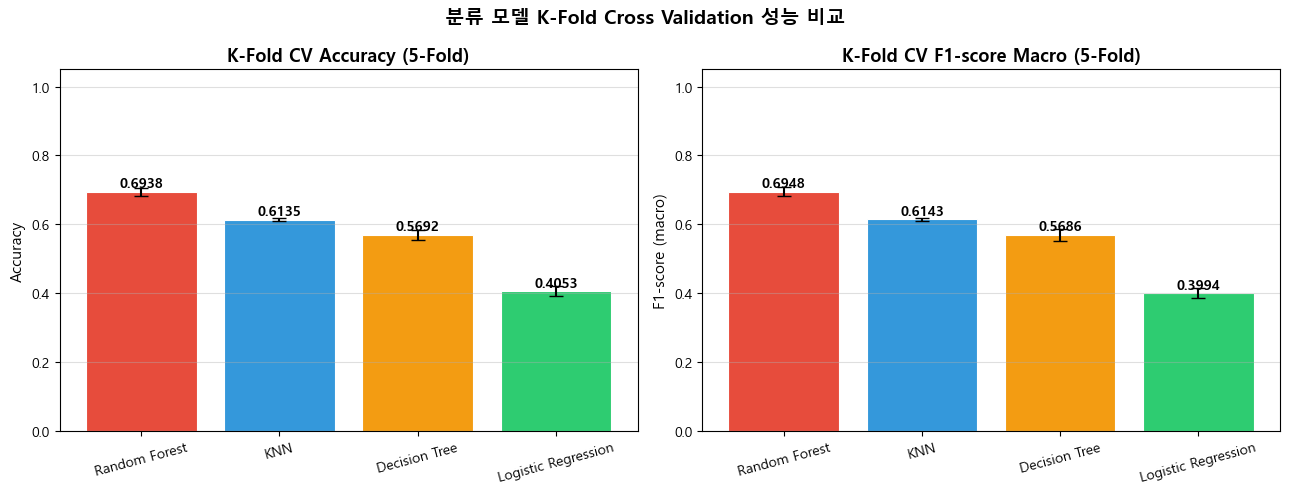

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_names = cv_df['Model'].tolist()
colors_bar  = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71']

for ax, metric, ylabel, title in zip(
    axes,
    ['Acc Mean', 'F1 Mean'],
    ['Accuracy', 'F1-score (macro)'],
    ['K-Fold CV Accuracy (5-Fold)', 'K-Fold CV F1-score Macro (5-Fold)']
):
    std_key = metric.replace('Mean', 'Std')
    bars = ax.bar(model_names, cv_df[metric], yerr=cv_df[std_key],
                  color=colors_bar[:len(model_names)], capsize=5, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, cv_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Classification Model K-Fold Cross Validation Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Visualization Interpretation**

- **Random Forest** achieved the highest performance in both Accuracy and F1-macro.
- **Logistic Regression** showed significantly low performance due to multicollinearity among features. Multicollinearity makes coefficient estimation in linear models unstable, degrading classification performance.
- Smaller error bars indicate more stable performance across folds. Random Forest demonstrates both high performance and stability simultaneously.

## Step 9. Optimal Model Selection and Validation

Select the model with the **highest F1-macro** from K-Fold CV results as the optimal model.

F1-macro is the simple average of F1-score per class,
making it the most appropriate evaluation metric for this analysis where
Underpriced / Fairly Priced / Overpriced classes are all equally important.

Re-train the selected optimal model on the training set (80%) and evaluate final performance on the validation set (20%).

In [10]:
best_model_name = cv_df.iloc[0]['Model']
best_model      = models[best_model_name]
print(f'Selected best model: {best_model_name}')

best_model.fit(X_train, y_train)
y_val_pred = best_model.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average='macro')

print(f'\nValidation set performance (20%, N={len(y_val)}):')
print(f'  Accuracy  = {val_acc:.4f}')
print(f'  F1-macro  = {val_f1:.4f}')

# Print per-class performance only (excluding accuracy/macro avg/weighted avg)
report = classification_report(y_val, y_val_pred,
                               target_names=['Underpriced', 'Fairly Priced', 'Overpriced'])
filtered_lines = [
    line for line in report.split('\n')
    if not any(x in line for x in ['accuracy', 'macro avg', 'weighted avg'])
]
print('\nClassification Report (Validation Set):')
print('\n'.join(filtered_lines))

선정된 최적 모델: Random Forest

검증 세트 성능 (20%, N=1439):
  Accuracy  = 0.7130
  F1-macro  = 0.7134

분류 리포트 (검증 세트):
               precision    recall  f1-score   support

  Underpriced       0.71      0.77      0.74       475
Fairly Priced       0.66      0.65      0.66       489
   Overpriced       0.77      0.72      0.74       475




**Classification Report Interpretation**

The meaning of each metric is as follows:
- **Precision**: The proportion of correct predictions when the model predicts a given class
- **Recall**: The proportion of actual instances of a class that the model correctly classified
- **F1-score**: Balanced score of Precision and Recall

Underpriced and Overpriced showed relatively high F1-scores of 0.74.
Fairly Priced, on the other hand, showed the lowest F1-score of 0.66 among the three classes.
This is because Fairly Priced is the middle class between Underpriced and Overpriced,
with unclear boundaries causing confusion with both classes — a natural phenomenon.

## Step 10. Confusion Matrix

The confusion matrix shows how accurately the model classified each class.

- **Diagonal (↘)**: Correctly predicted cases
- **Off-diagonal**: Incorrectly predicted cases (misclassification)

This allows us to identify **class-specific misclassification patterns** that cannot be captured by simple Accuracy alone.

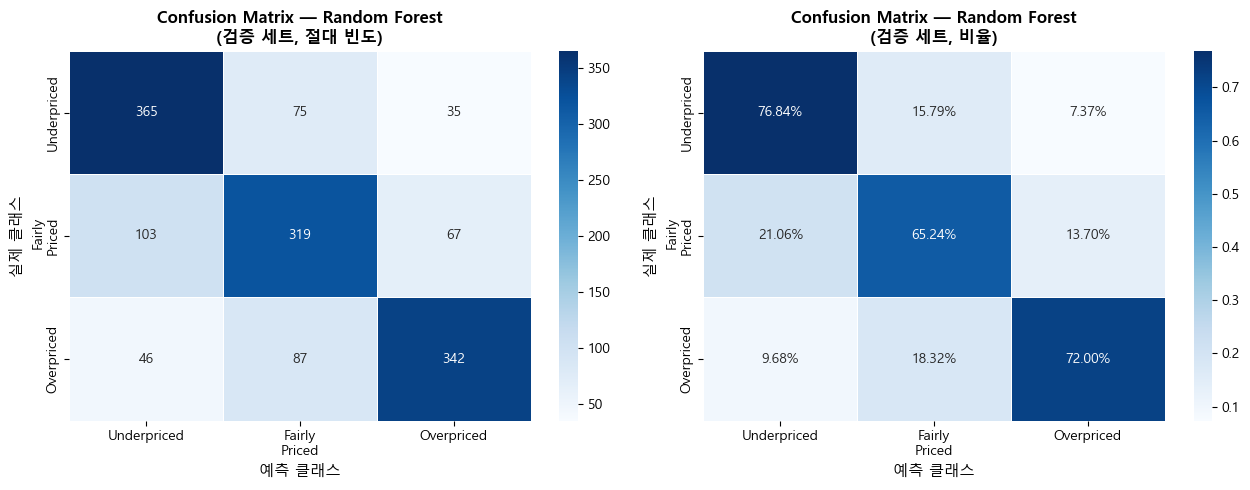

In [11]:
cm = confusion_matrix(y_val, y_val_pred)
class_labels_str = ['Underpriced', 'Fairly\nPriced', 'Overpriced']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_str, yticklabels=class_labels_str,
            linewidths=0.5, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_model_name}\n(Validation Set, Absolute Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=11)
axes[0].set_ylabel('Actual Class', fontsize=11)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_labels_str, yticklabels=class_labels_str,
            linewidths=0.5, ax=axes[1])
axes[1].set_title(f'Confusion Matrix — {best_model_name}\n(Validation Set, Proportions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Class', fontsize=11)
axes[1].set_ylabel('Actual Class', fontsize=11)

plt.tight_layout()
plt.show()

**Confusion Matrix Interpretation**

- **Underpriced**: Approximately 77% correctly classified; the remainder was mostly misclassified as Fairly Priced.
- **Fairly Priced**: Shows the lowest accuracy among the three classes. As the middle class between Underpriced and Overpriced, confusion with both classes due to unclear boundaries is a natural phenomenon.
- **Overpriced**: Approximately 72% correctly classified; misclassifications were mostly in the direction of Fairly Priced.
- Overall, the model tends to **predict toward the middle class (Fairly Priced)** when confidence is low.

## Step 11. Apply Classification to 54,805-Row Test Data

Re-train the optimal model on the **entire 7,192 rows**,
then apply classification to the large dataset of 54,805 vehicle records.

This allows us to identify the overall pricing tendency of vehicles in the dataset.

In [12]:
best_model.fit(X_clf, y_clf)
y_test_pred = best_model.predict(X_test_clf)

df_test['price_class'] = y_test_pred
df_test['price_label'] = df_test['price_class'].map({
    0: 'Underpriced', 1: 'Fairly Priced', 2: 'Overpriced'
})

test_counts = df_test['price_class'].value_counts().sort_index()
print('Classification results for 54,805-row test data:')
for cls, cnt in test_counts.items():
    lbl = {0: 'Underpriced', 1: 'Fairly Priced', 2: 'Overpriced'}[cls]
    print(f'  {cls} ({lbl}): {cnt:,} samples  ({cnt/len(df_test)*100:.1f}%)')

54,805행 테스트 데이터 분류 결과:
  0 (Underpriced): 20,554건  (37.5%)
  1 (Fairly Priced): 15,856건  (28.9%)
  2 (Overpriced): 18,395건  (33.6%)


## Step 12. Visualize Test Data Classification Results

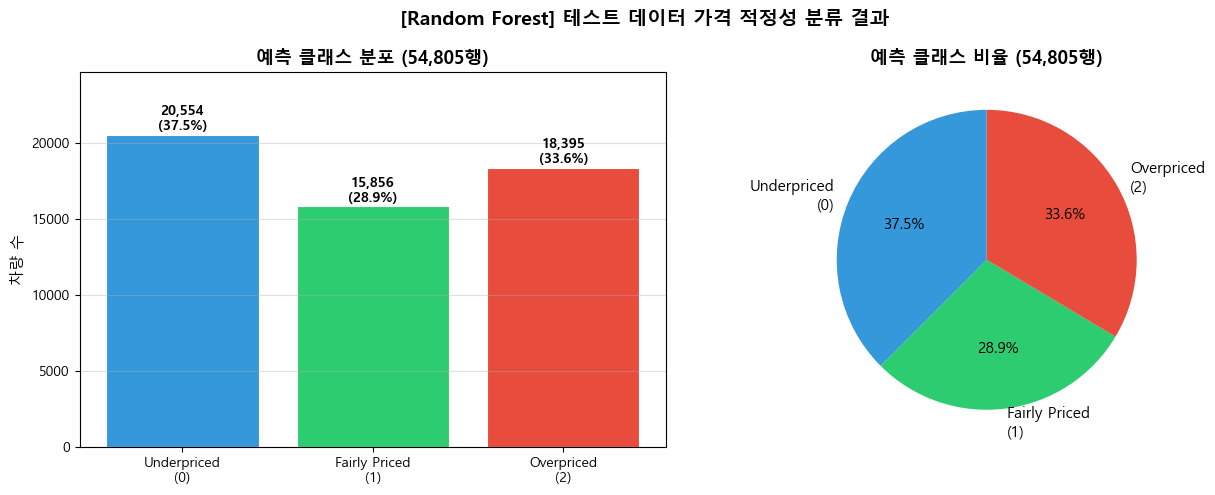

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

test_counts       = df_test['price_class'].value_counts().sort_index()
class_labels_test = ['Underpriced\n(0)', 'Fairly Priced\n(1)', 'Overpriced\n(2)']
colors            = ['#3498DB', '#2ECC71', '#E74C3C']

bars = axes[0].bar(class_labels_test, test_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, test_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
        f'{cnt:,}\n({cnt/len(df_test)*100:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Predicted Class Distribution (54,805 rows)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Vehicle Count', fontsize=11)
axes[0].set_ylim(0, test_counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.4)

axes[1].pie(
    test_counts.values, labels=class_labels_test, colors=colors,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Predicted Class Ratio (54,805 rows)', fontsize=13, fontweight='bold')

plt.suptitle(f'[{best_model_name}] Price Adequacy Classification Results on Test Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 13. Price Range Class Distribution Analysis

Divide the `price_log` (log price) of test data into 5 intervals
and analyze the price adequacy distribution by price range.

This allows us to identify whether under- or over-valuation tendencies are concentrated in specific price ranges.

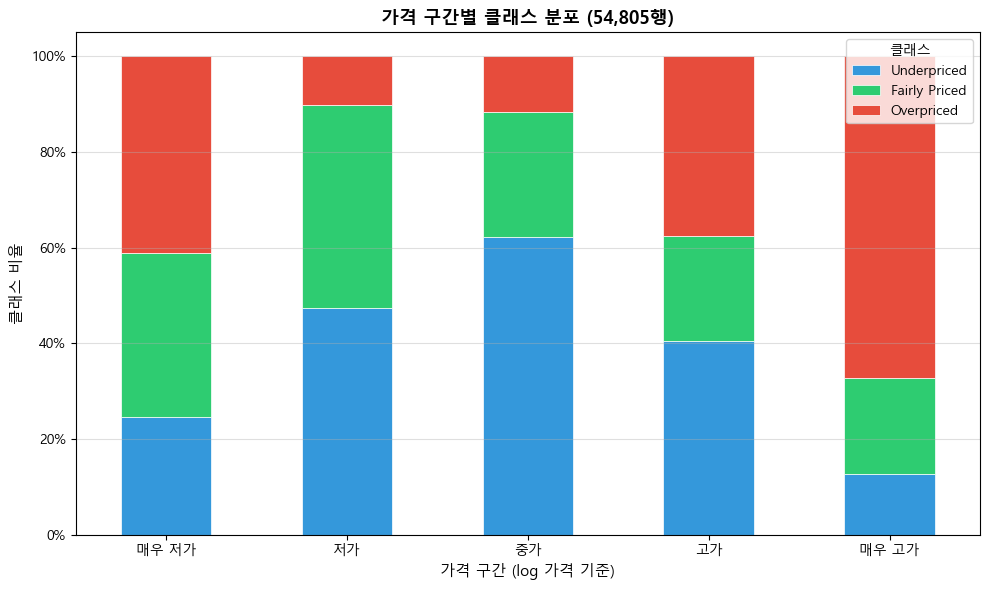

In [14]:
df_test['price_bin'] = pd.qcut(
    df_test['price_log'], q=5,
    labels=['Very Low', 'Low', 'Mid', 'High', 'Very High']
)

price_class_dist = (
    df_test.groupby(['price_bin', 'price_class'], observed=True)
    .size().unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
)
price_class_dist.columns = ['Underpriced', 'Fairly Priced', 'Overpriced']

fig, ax = plt.subplots(figsize=(10, 6))
price_class_dist.plot(kind='bar', stacked=True,
                      color=['#3498DB', '#2ECC71', '#E74C3C'],
                      edgecolor='white', linewidth=0.5, ax=ax)
ax.set_title('Class Distribution by Price Range (54,805 rows)', fontsize=13, fontweight='bold')
ax.set_xlabel('Price Range (based on log price)', fontsize=11)
ax.set_ylabel('Class Ratio', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Class', loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Price Range Distribution Interpretation**

- **Very Low Price**: The Overpriced ratio is highest. This means many cheap vehicles are overvalued relative to their fair price.
- **Low / Mid Price**: The Underpriced ratio is high, indicating that mid-to-low priced vehicles tend to be sold relatively cheaply.
- **High Price**: Underpriced and Overpriced appear at similar ratios, indicating mixed price adequacy.
- **Very High Price**: The Overpriced ratio is overwhelmingly high. The more expensive the vehicle, the stronger the tendency to be sold above its fair price.

> **Key Insight**: Overpriced tendencies are strong at both ends of the price spectrum (very low and very high), while Underpriced tendencies are prominent in the middle price range.

## Step 14. Dataset Pricing Tendency Analysis

From the 54,805-row classification results, identify the **class with the highest proportion**
to derive the overall pricing tendency of the dataset.

In [15]:
test_counts = df_test['price_class'].value_counts().sort_index()
label_map   = {0: 'Underpriced', 1: 'Fairly Priced', 2: 'Overpriced'}

dominant_class = test_counts.idxmax()
dominant_label = label_map[dominant_class]
dominant_pct   = test_counts.max() / len(df_test) * 100

print('=' * 55)
print('  Class proportions in 54,805-row test data')
print('=' * 55)
for cls, cnt in test_counts.items():
    marker = ' ◀ Most' if cls == dominant_class else ''
    print(f'  {label_map[cls]:15s}: {cnt:,} samples  ({cnt/len(df_test)*100:.1f}%){marker}')
print('=' * 55)
print()

if dominant_class == 0:
    print(f'→ Dominant class: Underpriced ({dominant_pct:.1f}%)')
    print()
    print('  Vehicles in this dataset are generally priced')
    print('  below the fair market value.')
    print('  In other words, this dataset represents a market with many undervalued vehicles.')
elif dominant_class == 1:
    print(f'→ Dominant class: Fairly Priced ({dominant_pct:.1f}%)')
    print()
    print('  Vehicles in this dataset are generally priced')
    print('  at fair market value.')
    print('  In other words, this dataset represents a market with well-priced vehicles.')
elif dominant_class == 2:
    print(f'→ Dominant class: Overpriced ({dominant_pct:.1f}%)')
    print()
    print('  Vehicles in this dataset are generally priced')
    print('  above the fair market value.')
    print('  In other words, this dataset represents a market with many overvalued vehicles.')

  54,805행 테스트 데이터 클래스 비율
  Underpriced    : 20,554건  (37.5%) ◀ 최다
  Fairly Priced  : 15,856건  (28.9%)
  Overpriced     : 18,395건  (33.6%)

→ 가장 많은 클래스: Underpriced (37.5%)

  해당 데이터셋의 차량들은 전반적으로 적정 가격보다
  낮은 가격으로 판매되는 경향이 있다.
  즉, 이 데이터셋은 전반적으로 저평가된 차량이 많은 시장이다.


## Step 15. Conclusion

### Analysis Summary

This notebook built a machine learning pipeline to classify vehicle price adequacy based on regression model residuals
and derived the overall pricing tendency of a large dataset.

### Label Generation

Predicted prices for 7,192 vehicles were calculated using the Enhanced Linear Regression model (including estimate_msrp)
and price adequacy labels were generated based on residuals.
The **percentile method** was adopted for label generation.
Since there is no absolute standard for vehicle fair pricing, judging by relative position within the entire data is rational,
and maintaining approximately 33% equal distribution across three classes ensured training stability for the classification model.

### Model Comparison (Stratified K-Fold Cross Validation)

**Stratified 5-Fold Cross Validation** was performed on 4 models.
Stratified K-Fold maintains the same class ratio as the original in each fold,
enabling stable and reliable performance evaluation.
Logistic Regression showed low performance due to multicollinearity among features,
while **Random Forest**, which is robust to multicollinearity, showed the best F1-macro performance and was selected as the optimal model.

### Dataset Pricing Tendency

Applying the selected Random Forest model to 54,805 rows of large-scale vehicle data,
the overall pricing tendency of the dataset was identified based on the class with the highest proportion.
Price range analysis also confirmed that Overpriced tendencies were prominent for very low and very high priced vehicles,
while Underpriced tendencies were prominent for mid-priced vehicles.

### Limitations and Future Work

- There is some inconsistency due to different scaling standards between training data (7,192 rows) and test data (54,805 rows). Applying the same scaler in the future can improve model consistency.
- Residual-based labels depend on the quality of the regression model, so using a more refined regression model could improve label quality.
- SMOTE was not applied due to no class imbalance, but re-evaluation is needed if label criteria change in the future.